## Project:LinkedIn Trend Analysis Using Latent Dirichlet Allocation(LDA)

## IMPORTING NECESSARY LIBRARIES

In [1]:
!pip install gensim


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import nltk
import gensim

## LOADING DATA

In [3]:
df=pd.read_csv('../data/postings.csv')
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


## SHAPE OF THE DATA

In [4]:
df.shape

(123849, 31)

## COLUMNS OF THE DATA

In [5]:
df.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='object')

## DATATYPES 

In [6]:
df.dtypes

job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies                       float64
original_listed_time          float64
remote_allowed                float64
job_posting_url                object
application_url                object
application_type               object
expiry                        float64
closed_time                   float64
formatted_experience_level     object
skills_desc                    object
listed_time                   float64
posting_domain                 object
sponsored                       int64
work_type                      object
currency    

## STATISTICAL DATA

In [7]:
df.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


## INFO OF THE DATA

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

## CHECKING DUPLICATES

In [9]:
df.duplicated().sum()

0

## CHECKING NULLS

In [10]:
df.isnull().sum()

job_id                             0
company_name                    1719
title                              0
description                        7
max_salary                     94056
pay_period                     87776
location                           0
company_id                      1717
views                           1689
med_salary                    117569
min_salary                     94056
formatted_work_type                0
applies                       100529
original_listed_time               0
remote_allowed                108603
job_posting_url                    0
application_url                36665
application_type                   0
expiry                             0
closed_time                   122776
formatted_experience_level     29409
skills_desc                   121410
listed_time                        0
posting_domain                 39968
sponsored                          0
work_type                          0
currency                       87776
c

## 1.	Preprocessing LinkedIn post data for noise removal and text normalization.

In [11]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


# Segregate the columns into categories
text_columns = ['title', 'description', 'location', 'formatted_work_type', 
                'job_posting_url', 'application_url', 'application_type', 
                'formatted_experience_level', 'skills_desc', 'posting_domain', 
                'work_type', 'currency', 'compensation_type']

numeric_columns = ['job_id', 'max_salary', 'views', 'med_salary', 'min_salary', 
                   'applies', 'original_listed_time', 'expiry', 'closed_time', 
                   'listed_time', 'sponsored', 'normalized_salary', 'zip_code', 'fips']

categorical_columns = ['company_name', 'company_id', 'remote_allowed']

# **1. Drop Columns with Too Many Missing Values**
#df.drop(columns=['remote_allowed', 'closed_time', 'applies'], inplace=True)

# **2. Fill Missing Categorical Values with 'Unknown'**
categorical_cols = ['company_name', 'pay_period', 'formatted_experience_level',
                    'posting_domain', 'work_type', 'application_url', 'compensation_type', 'currency']
for col in categorical_cols:
    df[col].fillna('Unknown', inplace=True)

# **3. Fill Missing Numerical Values with Median (-1 as Placeholder Alternative)**
numerical_cols = ['company_id', 'views', 'max_salary', 'min_salary', 'med_salary', 'normalized_salary', 'zip_code', 'fips']
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)  # Replace median with -1 if necessary

# **4. Drop Rows Where 'description' or 'skills_desc' is Missing**
df.dropna(subset=['description'], inplace=True)
df.dropna(subset=['skills_desc'], inplace=True)

# **5. Convert Data Types (if needed)**
df['company_id'] = df['company_id'].astype(int, errors='ignore')
df['views'] = df['views'].astype(int, errors='ignore')
df['zip_code'] = df['zip_code'].astype(int, errors='ignore')
df['fips'] = df['fips'].astype(int, errors='ignore')

# **6. Text Preprocessing**

# Fill nulls in text columns with the most frequent value (mode)
for column in text_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Text preprocessing function
def preprocess_text(text):
    if pd.isna(text):  # Handle missing values (though we already filled nulls)
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove special characters, numbers, and extra spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize text
    tokens = word_tokenize(text)
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return ' '.join(tokens)

# Apply preprocessing to all text columns
for column in text_columns:
    df[f'cleaned_{column}'] = df[column].apply(preprocess_text)

# **7. Final Check**
print(df.isnull().sum())

# Check the cleaned data
df.head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


job_id                                   0
company_name                             0
title                                    0
description                              0
max_salary                               0
pay_period                               0
location                                 0
company_id                               0
views                                    0
med_salary                               0
min_salary                               0
formatted_work_type                      0
applies                               2192
original_listed_time                     0
remote_allowed                        2363
job_posting_url                          0
application_url                          0
application_type                         0
expiry                                   0
closed_time                           2403
formatted_experience_level               0
skills_desc                              0
listed_time                              0
posting_dom

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,cleaned_formatted_work_type,cleaned_job_posting_url,cleaned_application_url,cleaned_application_type,cleaned_formatted_experience_level,cleaned_skills_desc,cleaned_posting_domain,cleaned_work_type,cleaned_currency,cleaned_compensation_type
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458,20,25.5,...,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,requirement seeking college graduate student a...,unknown,fulltime,usd,basesalary
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719,8,25.5,...,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,currently accepting resume foh asisstant resta...,unknown,fulltime,usd,basesalary
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262,16,25.5,...,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,position requires baseline understanding onlin...,unknown,fulltime,usd,basesalary
8,1218575,Children's Nebraska,Respiratory Therapist,"At Children’s, the region’s only full-service ...",80000.0,Unknown,"Omaha, NE",721189,3,25.5,...,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,wwwchildrensnebraskaorg,offsiteapply,unknown,requires ability communicate effective verball...,unknown,fulltime,unknown,unknown
9,2264355,Bay West Church,Worship Leader,It is an exciting time to be a part of our chu...,80000.0,MONTHLY,"Palm Bay, FL",28631247,5,350.0,...,parttime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,knowledge skill ability proficient computer te...,unknown,parttime,usd,basesalary


In [12]:
# Identify columns with 'cleaned_' prefix
cleaned_cols = [col for col in df.columns if col.startswith('cleaned_')]

# Extract original column names by removing the 'cleaned_' prefix
original_cols = [col.replace('cleaned_', '') for col in cleaned_cols]

# Drop the original columns that have a corresponding cleaned version
df.drop(columns=original_cols, inplace=True)

# Verify the final columns
print(df.columns)

Index(['job_id', 'company_name', 'max_salary', 'pay_period', 'company_id',
       'views', 'med_salary', 'min_salary', 'applies', 'original_listed_time',
       'remote_allowed', 'expiry', 'closed_time', 'listed_time', 'sponsored',
       'normalized_salary', 'zip_code', 'fips', 'cleaned_title',
       'cleaned_description', 'cleaned_location',
       'cleaned_formatted_work_type', 'cleaned_job_posting_url',
       'cleaned_application_url', 'cleaned_application_type',
       'cleaned_formatted_experience_level', 'cleaned_skills_desc',
       'cleaned_posting_domain', 'cleaned_work_type', 'cleaned_currency',
       'cleaned_compensation_type'],
      dtype='object')


In [13]:
# Rename columns by removing 'cleaned_' prefix
df.rename(columns=lambda col: col.replace('cleaned_', '') if col.startswith('cleaned_') else col, inplace=True)

# Verify the updated column names
print(df.columns)

Index(['job_id', 'company_name', 'max_salary', 'pay_period', 'company_id',
       'views', 'med_salary', 'min_salary', 'applies', 'original_listed_time',
       'remote_allowed', 'expiry', 'closed_time', 'listed_time', 'sponsored',
       'normalized_salary', 'zip_code', 'fips', 'title', 'description',
       'location', 'formatted_work_type', 'job_posting_url', 'application_url',
       'application_type', 'formatted_experience_level', 'skills_desc',
       'posting_domain', 'work_type', 'currency', 'compensation_type'],
      dtype='object')


In [14]:
df.shape

(2439, 31)

In [15]:
##replacing the unknown value with the mode

In [16]:
# Fill missing categorical values with mode (most frequent value)
categorical_cols = ['company_name', 'pay_period', 'formatted_experience_level',
                    'posting_domain', 'work_type', 'application_url', 'compensation_type', 'currency']

for col in categorical_cols:
    if df[col].isnull().sum() > 0:  # Check if there are missing values
        df[col].fillna(df[col].mode()[0], inplace=True)  # Fill with mode

# Verify if missing values are handled
print(df.isnull().sum())

job_id                           0
company_name                     0
max_salary                       0
pay_period                       0
company_id                       0
views                            0
med_salary                       0
min_salary                       0
applies                       2192
original_listed_time             0
remote_allowed                2363
expiry                           0
closed_time                   2403
listed_time                      0
sponsored                        0
normalized_salary                0
zip_code                         0
fips                             0
title                            0
description                      0
location                         0
formatted_work_type              0
job_posting_url                  0
application_url                  0
application_type                 0
formatted_experience_level       0
skills_desc                      0
posting_domain                   0
work_type           

In [17]:
##checking if there are any unknowns left

In [18]:
# Replace missing values with suitable defaults
df['applies'].fillna(0, inplace=True)  # Assuming 0 applies if missing
df['remote_allowed'].fillna('Unknown', inplace=True)  # Assuming 'Unknown' if missing
df['closed_time'].fillna(df['expiry'], inplace=True)  # Assuming missing closed_time = expiry

# Debugging: Check if nulls remain
print(df.isnull().sum())


job_id                        0
company_name                  0
max_salary                    0
pay_period                    0
company_id                    0
views                         0
med_salary                    0
min_salary                    0
applies                       0
original_listed_time          0
remote_allowed                0
expiry                        0
closed_time                   0
listed_time                   0
sponsored                     0
normalized_salary             0
zip_code                      0
fips                          0
title                         0
description                   0
location                      0
formatted_work_type           0
job_posting_url               0
application_url               0
application_type              0
formatted_experience_level    0
skills_desc                   0
posting_domain                0
work_type                     0
currency                      0
compensation_type             0
dtype: i

## 2.	Applying TF-IDF for weighting important terms.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Define relevant text columns
relevant_columns = ['title', 'description', 'skills_desc', 'formatted_experience_level', 'posting_domain', 'work_type', 'currency', 'location']

# Combine these columns into a single text column
df['combined_text'] = df[relevant_columns].astype(str).apply(lambda row: ' '.join(row), axis=1)

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the combined text data
tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text'])

# Get the terms and their corresponding TF-IDF scores
terms = tfidf_vectorizer.get_feature_names_out()

# Add TF-IDF scores back to the original DataFrame
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=terms, index=df.index)
df = pd.concat([df, df_tfidf], axis=1)

# Display top terms with the highest TF-IDF scores
top_terms = df_tfidf.max(axis=0).sort_values(ascending=False).head(10)
print(top_terms)

kofax      0.883605
deli       0.881569
cognos     0.847186
release    0.841478
ach        0.831550
massage    0.821290
crane      0.820413
pickle     0.814564
litammy    0.813247
tax        0.804863
dtype: float64


## LDA fitting

In [20]:
from sklearn.decomposition import LatentDirichletAllocation

# Define the number of topics (adjustable)
num_topics =7 

# Fit LDA model using the TF-IDF matrix you already computed
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_matrix = lda_model.fit_transform(tfidf_matrix)  # Using your existing tfidf_matrix

# Function to display topics
def display_topics(model, feature_names, num_top_words):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")

# Show top words for each topic
display_topics(lda_model, tfidf_vectorizer.get_feature_names_out(), 10)

Topic 1: careerstaff, rn, nurse, registered, healthcare, unlimited, career, nursing, blood, care
Topic 2: hygienist, fullmind, astrophysics, arch, konecranes, ywca, select, patientfocused, qualificationscurrent, cordless
Topic 3: midland, umc, citadel, feinblatt, standarduniversal, sq, physicals, peoplesoft, lynnwood, simulator
Topic 4: braun, walmart, generator, power, cna, bathing, denture, bedtime, dfs, rix
Topic 5: operative, surgical, surgery, lawn, referring, capstone, roadway, coverageemployee, insurancespouse, wcompany
Topic 6: volunteer, work, patient, service, experience, care, team, customer, skill, project
Topic 7: disaster, surveillance, dap, oversight, frasco, investigation, investigator, library, relief, preparedness


In [21]:
!pip install wordcloud


Topic 1: careerstaff, rn, nurse, registered, healthcare, unlimited, career, nursing, blood, care
Topic 2: hygienist, fullmind, astrophysics, arch, konecranes, ywca, select, patientfocused, qualificationscurrent, cordless
Topic 3: midland, umc, citadel, feinblatt, standarduniversal, sq, physicals, peoplesoft, lynnwood, simulator
Topic 4: braun, walmart, generator, power, cna, bathing, denture, bedtime, dfs, rix
Topic 5: operative, surgical, surgery, lawn, referring, capstone, roadway, coverageemployee, insurancespouse, wcompany
Topic 6: volunteer, work, patient, service, experience, care, team, customer, skill, project
Topic 7: disaster, surveillance, dap, oversight, frasco, investigation, investigator, library, relief, preparedness
    Topic 1   Topic 2   Topic 3   Topic 4   Topic 5   Topic 6   Topic 7  \
0  0.011121  0.011118  0.011118  0.011118  0.011118  0.933287  0.011118   
1  0.018156  0.018144  0.178057  0.018144  0.018144  0.731205  0.018149   
2  0.014006  0.013997  0.099436  

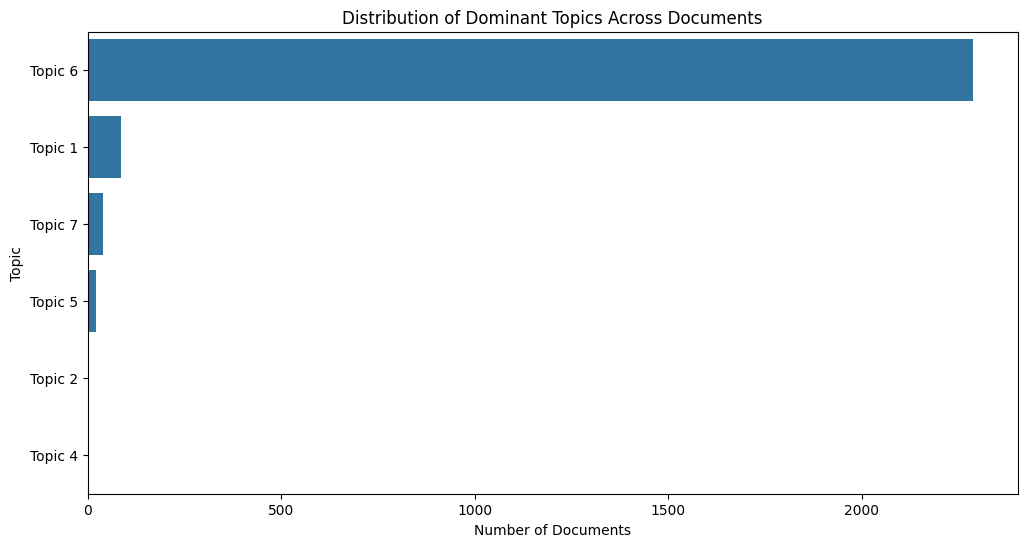

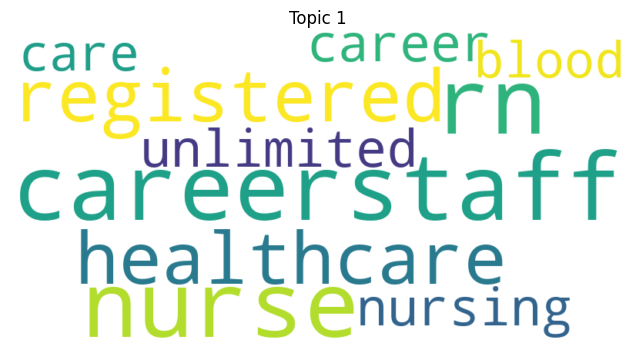

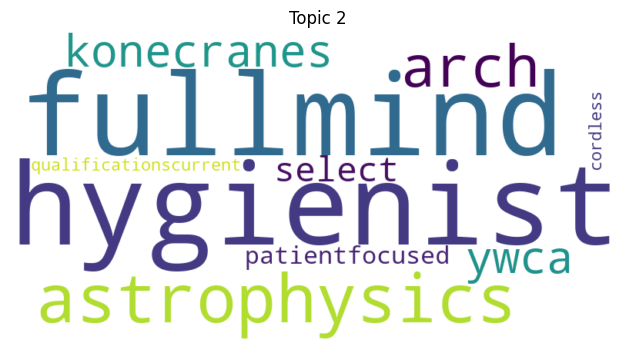

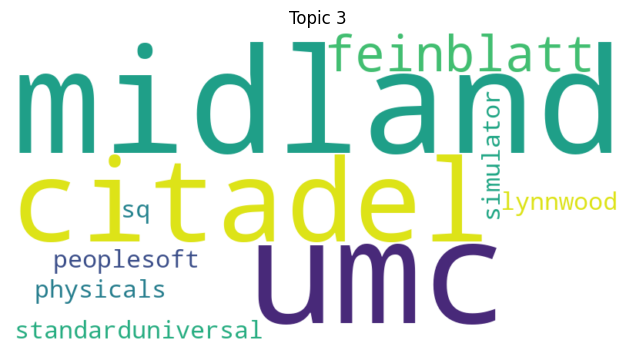

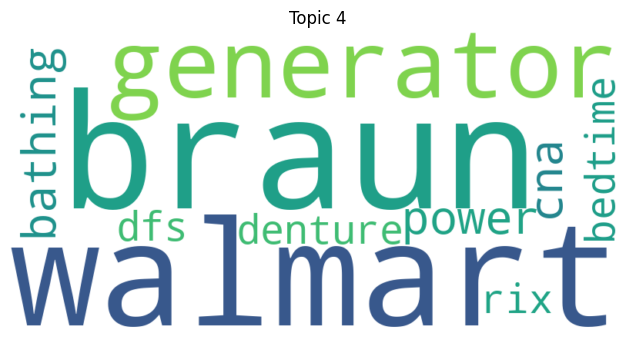

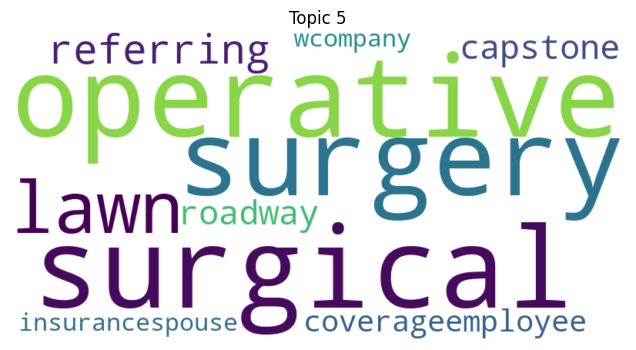

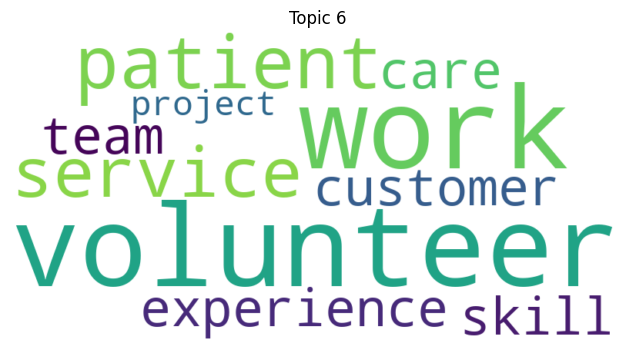

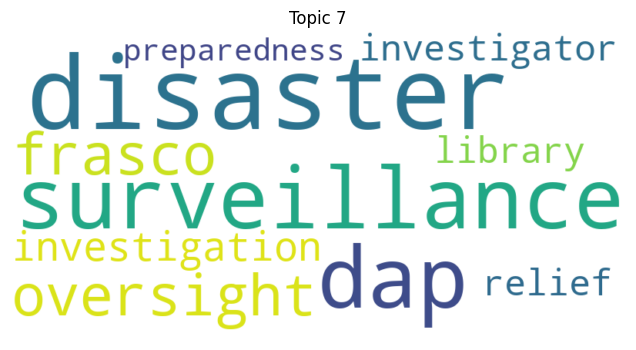

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

# Define number of topics
num_topics = 7  

# Fit LDA model using the TF-IDF matrix
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_matrix = lda_model.fit_transform(tfidf_matrix)

# Function to extract top words for each topic
def display_topics(model, feature_names, num_top_words):
    topic_keywords = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]]
        topic_keywords[f"Topic {topic_idx + 1}"] = top_words
        print(f"Topic {topic_idx + 1}: {', '.join(top_words)}")
    return topic_keywords

# Extract top words for each topic
topic_keywords = display_topics(lda_model, tfidf_vectorizer.get_feature_names_out(), 10)

# Assign dominant topic to each document
df_topics = pd.DataFrame(lda_matrix, columns=[f"Topic {i+1}" for i in range(num_topics)])
df_topics['Dominant_Topic'] = df_topics.idxmax(axis=1)

# Print first few rows
print(df_topics.head())

# --- Visualizing Topic Distributions ---
# 1. Topic Distribution across Documents
plt.figure(figsize=(12,6))
sns.countplot(y=df_topics['Dominant_Topic'], order=df_topics['Dominant_Topic'].value_counts().index)
plt.title("Distribution of Dominant Topics Across Documents")
plt.xlabel("Number of Documents")
plt.ylabel("Topic")
plt.show()

# 2. Word Clouds for Topics
for topic, words in topic_keywords.items():
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(words))
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(topic)
    plt.show()


In [23]:
df.head()

,job_id,company_name,max_salary,pay_period,company_id,views,med_salary,min_salary,applies,original_listed_time,...,zonethe,zonewaterfood,zoo,zoom,zoominfo,zoommust,zpa,zr,zscaler,zuken
0,921716,Corcoran Sawyer Smith,20.0,HOURLY,2774458,20,25.5,17.0,2.0,1.713398e+12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10998357,The National Exemplar,65000.0,YEARLY,64896719,8,25.5,45000.0,0.0,1.713278e+12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,23221523,"Abrams Fensterman, LLP",175000.0,YEARLY,766262,16,25.5,140000.0,0.0,1.712896e+12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1218575,Children's Nebraska,80000.0,Unknown,721189,3,25.5,60000.0,0.0,1.712348e+12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2264355,Bay West Church,80000.0,MONTHLY,28631247,5,350.0,60000.0,0.0,1.712456e+12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
pd.set_option('display.max_columns', None)  

In [25]:
print(df.columns)  # Check if 'title' exists
print(df.dtypes)   # Check data types of all columns
print(df.head())   # Display the first few rows




Index(['job_id', 'company_name', 'max_salary', 'pay_period', 'company_id',
       'views', 'med_salary', 'min_salary', 'applies', 'original_listed_time',
       ...
       'zonethe', 'zonewaterfood', 'zoo', 'zoom', 'zoominfo', 'zoommust',
       'zpa', 'zr', 'zscaler', 'zuken'],
      dtype='object', length=38496)
job_id            int64
company_name     object
max_salary      float64
pay_period       object
company_id        int32
                 ...   
zoommust        float64
zpa             float64
zr              float64
zscaler         float64
zuken           float64
Length: 38496, dtype: object


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [26]:
matching_cols = [col for col in df.columns if 'title' in col.lower()]
print(matching_cols)  # Find columns related to job title


['title', 'descriptiontitle', 'detailstitle', 'entitled', 'entitlement', 'positiontitle', 'title', 'titlecloud', 'titleservicenow', 'titlesrecord', 'titletechnical']


In [27]:
print([col for col in df.columns if 'title' in col.lower()])
print(df[['title']].head())  # Check the 'title' column


['title', 'descriptiontitle', 'detailstitle', 'entitled', 'entitlement', 'positiontitle', 'title', 'titlecloud', 'titleservicenow', 'titlesrecord', 'titletechnical']
                                              title  title
0                             marketing coordinator    0.0
2                       assitant restaurant manager    0.0
3  senior elder law trust estate associate attorney    0.0
8                             respiratory therapist    0.0
9                                    worship leader    0.0


In [28]:
df = df.loc[:, ~df.columns.duplicated()]  # Remove duplicate columns
df = df.loc[:, (df.dtypes != 'float64')]  # Drop numeric columns if they exist
df.columns

Index(['job_id', 'company_name', 'pay_period', 'company_id', 'views',
       'remote_allowed', 'sponsored', 'zip_code', 'fips', 'title',
       'description', 'location', 'formatted_work_type', 'job_posting_url',
       'application_url', 'application_type', 'formatted_experience_level',
       'skills_desc', 'posting_domain', 'work_type', 'currency',
       'compensation_type', 'combined_text'],
      dtype='object')

In [29]:
df.head()

,job_id,company_name,pay_period,company_id,views,remote_allowed,sponsored,zip_code,fips,title,description,location,formatted_work_type,job_posting_url,application_url,application_type,formatted_experience_level,skills_desc,posting_domain,work_type,currency,compensation_type,combined_text
0,921716,Corcoran Sawyer Smith,HOURLY,2774458,20,Unknown,0,8540,34021,marketing coordinator,job descriptiona leading real estate firm new ...,princeton nj,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,requirement seeking college graduate student a...,unknown,fulltime,usd,basesalary,marketing coordinator job descriptiona leading...
2,10998357,The National Exemplar,YEARLY,64896719,8,Unknown,0,45202,39061,assitant restaurant manager,national exemplar accepting application assist...,cincinnati oh,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,currently accepting resume foh asisstant resta...,unknown,fulltime,usd,basesalary,assitant restaurant manager national exemplar ...
3,23221523,"Abrams Fensterman, LLP",YEARLY,766262,16,Unknown,0,11040,36059,senior elder law trust estate associate attorney,senior associate attorney elder law trust esta...,new hyde park ny,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,position requires baseline understanding onlin...,unknown,fulltime,usd,basesalary,senior elder law trust estate associate attorn...
8,1218575,Children's Nebraska,Unknown,721189,3,Unknown,0,68102,31055,respiratory therapist,childrens region fullservice pediatric healthc...,omaha ne,fulltime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,wwwchildrensnebraskaorg,offsiteapply,unknown,requires ability communicate effective verball...,unknown,fulltime,unknown,unknown,respiratory therapist childrens region fullser...
9,2264355,Bay West Church,MONTHLY,28631247,5,Unknown,0,32905,12009,worship leader,exciting time part church looking right energe...,palm bay fl,parttime,httpswwwlinkedincomjobsviewtrkjobsbizpremsrch,unknown,complexonsiteapply,unknown,knowledge skill ability proficient computer te...,unknown,parttime,usd,basesalary,worship leader exciting time part church looki...


In [30]:
print(df.columns)


Index(['job_id', 'company_name', 'pay_period', 'company_id', 'views',
       'remote_allowed', 'sponsored', 'zip_code', 'fips', 'title',
       'description', 'location', 'formatted_work_type', 'job_posting_url',
       'application_url', 'application_type', 'formatted_experience_level',
       'skills_desc', 'posting_domain', 'work_type', 'currency',
       'compensation_type', 'combined_text'],
      dtype='object')


## 4.	Visualizing results through topic distributions, word clouds, and temporal trend charts.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load dataset (Ensure df is correctly loaded before proceeding)
if 'df' not in locals() or df is None:
    raise NameError("DataFrame 'df' is not defined. Please load your dataset.")

# Ensure dataset has necessary columns
required_columns = ['title', 'description', 'skills_desc', 
                    'formatted_experience_level', 'posting_domain', 'work_type', 
                    'currency', 'location']

for col in required_columns:
    if col not in df.columns:
        raise KeyError(f"Dataset must contain '{col}' column.")

# Set 'title' as the index
df.set_index('title', inplace=True)

# Ensure 'title' column is correctly processed
df = df.dropna(subset=['description', 'skills_desc', 'formatted_experience_level', 
                       'posting_domain', 'work_type', 'currency', 'location'])  # Remove rows with NaN values in essential columns

title_options = sorted(df.index.unique().tolist())

if not title_options:
    raise ValueError("No valid job titles found in 'title' column.")

# Dropdown widget to select Job Title
job_title_widget = widgets.Dropdown(
    options=title_options,
    description='Job Title:',
    disabled=False
)

output_area = widgets.Output()
display(job_title_widget, output_area)

def plot_job_trends(job_title):
    with output_area:
        clear_output(wait=True)
        display(job_title_widget)  # Re-display the widget
        
        print(f"Selected Job Title: {job_title}")
        
        # Filter the dataset based on selected job title
        if job_title not in df.index:
            print("No data available for the selected job title.")
            return
        
        filtered_df = df[df.index == job_title]
        
        # Create subplots to visualize the trends
        fig, axes = plt.subplots(3, 3, figsize=(15, 12))
        axes = axes.flatten()
        
        # Plot trends for each metric
        metrics = [
            ('description', 'Description Length'),
            ('skills_desc', 'Skills Description Length'),
            ('formatted_experience_level', 'Experience Level'),
            ('posting_domain', 'Posting Domain'),
            ('work_type', 'Work Type'),
            ('currency', 'Currency'),
            ('location', 'Location')
        ]
        
        for idx, (col, title) in enumerate(metrics):
            if col in filtered_df.columns:
                # Plotting logic varies based on column type
                if filtered_df[col].dtype == 'O':  # Categorical or text data
                    filtered_df[col].value_counts().plot(kind='bar', ax=axes[idx], title=title)
                    axes[idx].set_ylabel("Count")
                else:  # Numerical data
                    sns.lineplot(data=filtered_df, x=filtered_df.index, y=col, ax=axes[idx])
                    axes[idx].set_ylabel(col)
                axes[idx].set_title(title)
        
        plt.tight_layout()
        plt.show()

# Attach event listener to the dropdown widget
job_title_widget.observe(lambda change: plot_job_trends(change.new), names='value')


Dropdown(description='Job Title:', options=('ab initio etl senior developer', 'ac mechanic', 'account executiv…

Output()

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import ipywidgets as widgets
from IPython.display import display, clear_output

# Load dataset (Ensure df is correctly loaded before proceeding)
if 'df' not in locals() or df is None:
    raise NameError("DataFrame 'df' is not defined. Please load your dataset.")

# Ensure dataset has necessary columns
required_columns = ['title', 'description', 'skills_desc', 
                    'formatted_experience_level', 'posting_domain', 'work_type', 
                    'currency', 'location']

for col in required_columns:
    if col not in df.columns:
        raise KeyError(f"Dataset must contain '{col}' column.")

# Set 'title' as the index
df.set_index('title', inplace=True)

# Ensure essential columns are not empty
df = df.dropna(subset=['description', 'skills_desc', 'formatted_experience_level', 
                       'posting_domain', 'work_type', 'currency', 'location'])  

title_options = sorted(df.index.unique().tolist())

if not title_options:
    raise ValueError("No valid job titles found in 'title' column.")

# Dropdown widget to select Job Title
job_title_widget = widgets.Dropdown(
    options=title_options,
    description='Job Title:',
    disabled=False
)

output_area = widgets.Output()
display(job_title_widget, output_area)

def plot_job_trends(job_title):
    with output_area:
        clear_output(wait=True)
        display(job_title_widget)  # Re-display the widget
        
        print(f"Selected Job Title: {job_title}")
        
        # Filter dataset for selected job title
        if job_title not in df.index:
            print("No data available for the selected job title.")
            return
        
        filtered_df = df[df.index == job_title]

        # Convert description and skills to their length (word count)
        filtered_df['description_length'] = filtered_df['description'].apply(lambda x: len(str(x).split()))
        filtered_df['skills_length'] = filtered_df['skills_desc'].apply(lambda x: len(str(x).split()))

        # Create subplots
        fig, axes = plt.subplots(3, 3, figsize=(18, 12))
        axes = axes.flatten()

        metrics = [
            ('description_length', 'Description Word Count', 'line'),
            ('skills_length', 'Skills Word Count', 'line'),
            ('formatted_experience_level', 'Experience Level Distribution', 'bar'),
            ('posting_domain', 'Job Posting Domain', 'bar'),
            ('work_type', 'Work Type Distribution', 'bar'),
            ('currency', 'Currency Distribution', 'bar'),
            ('location', 'Job Location Distribution', 'bar')
        ]
        
        for idx, (col, title, chart_type) in enumerate(metrics):
            if col in filtered_df.columns:
                if chart_type == 'bar':
                    filtered_df[col].value_counts().plot(kind='bar', ax=axes[idx], title=title, color='teal')
                    axes[idx].set_ylabel("Count")
                else:  # Line chart for trends
                    sns.lineplot(data=filtered_df, x=filtered_df.index, y=col, ax=axes[idx], marker="o")
                    axes[idx].set_ylabel(col)
                    axes[idx].set_xlabel("Job Postings")

                axes[idx].set_title(title)

        plt.tight_layout()
        plt.show()

# Attach event listener to the dropdown widget
job_title_widget.observe(lambda change: plot_job_trends(change.new), names='value')


KeyError: "Dataset must contain 'title' column."